In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/12
    print("準備完了！このまま下のセルを実行できます。")

# 12.1 主成分分析 (Principal Component Analysis: PCA)

本ノートブックでは、非教師あり次元削減および特徴抽出の最重要古典手法である **主成分分析 (PCA)** を学びます。
高次元のデータ空間（例えば画像のピクセル空間）において、実際のデータは全ての次元に一様に分布しているわけではなく、低次元の多様体（manifold）の近傍に集中していることがよくあります。次元削減は、そのようなデータの固有の低次元構造を捉え、情報をできるだけ保持したまま低次元表現を得るための動機に基づいています。

主成分分析には、2つの等価な定式化が存在します：
1. **最大分散の定式化 (Maximum Variance Formulation)**: データを低次元空間に射影した際の、射影後のデータの分散が最大となるような直交座標系を見つけるアプローチです。
2. **最小再構成誤差の定式化 (Minimum Error Formulation)**: 元のデータ点と、それを低次元部分空間に射影した点との間の二乗誤差（再構成誤差）の総和が最小となるような部分空間を見つけるアプローチです。

射影後の最大分散定式化および直交補空間への最小二乗再構成誤差定式化の導出、手書き数字データに対する **平均画像と主成分固有ベクトル（固有数字: Eigen-digits, PRML Figure 12.3）**、成分数 $M$ の増加に伴う **画像の段階的再構成（PRML Figure 12.4）**、および Old Faithful 間欠泉データを用いた **主成分白色化（Whitening, PRML Figure 12.6）** を完全実装・再現します。

## 12.1.1 最大分散と最小誤差の定式化

主成分分析の2つの視点を数理的に導出します。

### 最大分散の定式化 (Maximum Variance)
中心化されたデータ行ベクトル $\mathbf{x}_n - \bar{\mathbf{x}}$ に対し、次元を1次元に落とすことを考えます。単位ベクトル $\mathbf{u}_1$（$\mathbf{u}_1^{\mathrm{T}}\mathbf{u}_1 = 1$）への射影されたデータの分散は以下のように表されます：
$$ \frac{1}{N} \sum_{n=1}^N (\mathbf{u}_1^{\mathrm{T}}\mathbf{x}_n - \mathbf{u}_1^{\mathrm{T}}\bar{\mathbf{x}})^2 = \mathbf{u}_1^{\mathrm{T}}\mathbf{S}\mathbf{u}_1 $$
ここで $\mathbf{S} = \frac{1}{N}\sum_{n=1}^N (\mathbf{x}_n - \bar{\mathbf{x}})(\mathbf{x}_n - \bar{\mathbf{x}})^{\mathrm{T}}$ はデータ共分散行列です。
この分散を最大化するため、ラグランジュ乗数 $\lambda_1$ を用いて制約条件 $\mathbf{u}_1^{\mathrm{T}}\mathbf{u}_1 = 1$ を組み込んだラグランジュ関数を定義します：
$$ \max_{\mathbf{u}_1} \mathbf{u}_1^{\mathrm{T}}\mathbf{S}\mathbf{u}_1 - \lambda_1(\mathbf{u}_1^{\mathrm{T}}\mathbf{u}_1 - 1) $$
これを $\mathbf{u}_1$ に関して微分し、0とおくと以下の固有値方程式が得られます：
$$ \mathbf{S}\mathbf{u}_1 = \lambda_1 \mathbf{u}_1 $$
したがって、射影分散は $\mathbf{u}_1^{\mathrm{T}}\mathbf{S}\mathbf{u}_1 = \lambda_1$ となり、分散を最大にする $\mathbf{u}_1$ は $\mathbf{S}$ の最大固有値に対応する固有ベクトル（第1主成分）となります。$M$ 成分に拡張する場合、上位 $M$ 個の固有値に対応する固有ベクトルを選択します。

### 最小再構成誤差の定式化 (Minimum Error)
もう一つの視点は、データ $\mathbf{x}_n$ を完全な $D$ 次元の正規直交基底で表現し、それを $M$ 個の基底で近似するアプローチです：
$$ \mathbf{x}_n = \bar{\mathbf{x}} + \sum_{i=1}^D z_{ni}\mathbf{u}_i \approx \bar{\mathbf{x}} + \sum_{i=1}^M z_{ni}\mathbf{u}_i = \hat{\mathbf{x}}_n $$
この近似表現における再構成誤差（残差）の二乗和を最小化する目的関数 $J$ を定義します：
$$ J = \frac{1}{N}\sum_{n=1}^N \|\mathbf{x}_n - \hat{\mathbf{x}}_n\|^2 $$
この誤差関数を最小化するように基底 $\mathbf{u}_i$ と係数 $z_{ni}$ を最適化すると、驚くべきことに最大分散の定式化と全く同一の解、すなわち $\mathbf{S}$ の固有ベクトルが得られます。さらに、再構成誤差の最小値は捨てられた成分に対応する固有値の和となります：
$$ J = \sum_{i=M+1}^D \lambda_i $$
これは、情報損失（再構成誤差）を最小にするためには、小さい固有値を持つ方向の成分を捨てるべきであるという直感と一致します。

Plot saved to: result/fig12_3_pca_eigen_digits.png


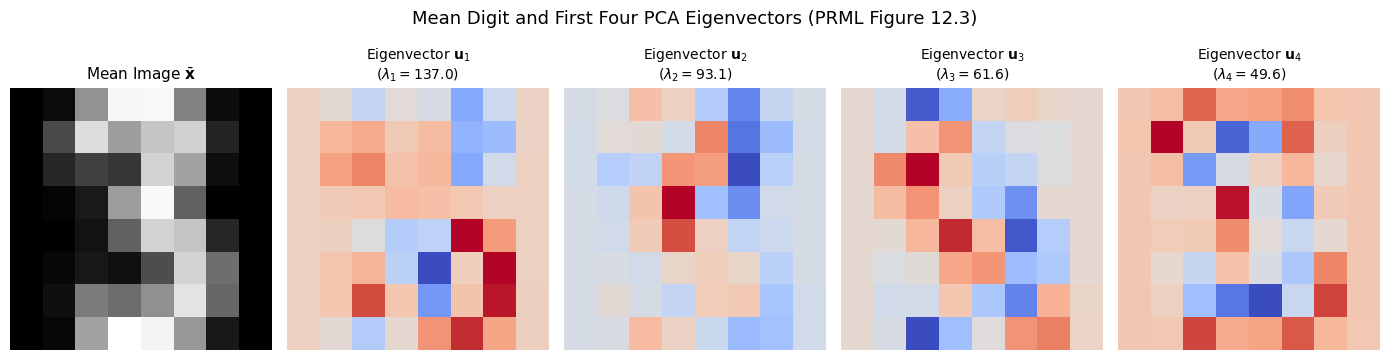

Plot saved to: result/fig12_4_pca_reconstruction_steps.png


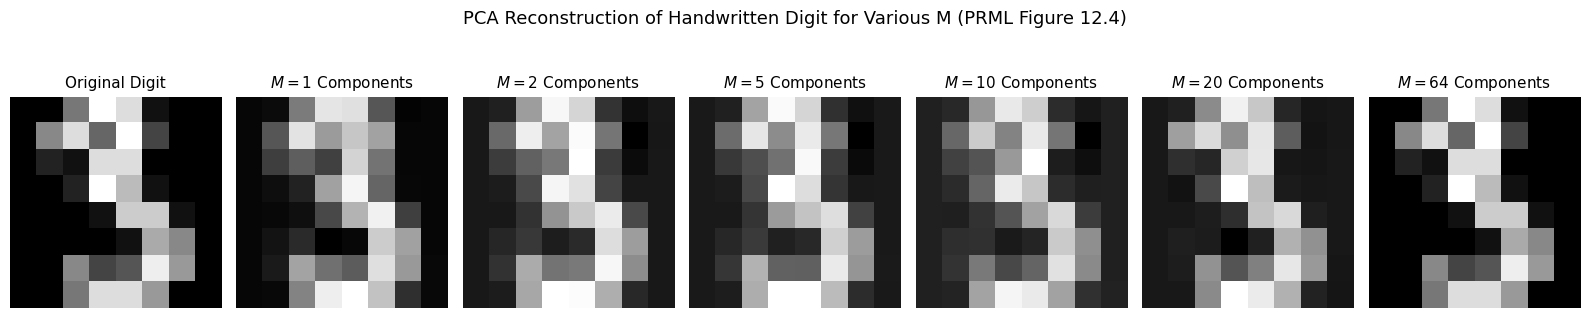

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from common.plot_utils import save_plot, setup_style
from common.pca_ppca_utils import PCA
setup_style()

# 手書き数字データの読み込み (8x8 = 64次元)
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

# 数字 '3' のサブセットを選択 (PRML Figure 12.3 に準拠)
mask_3 = (y_digits == 3)
X_threes = X_digits[mask_3]

# PCA モデルの適合
pca = PCA(n_components=64).fit(X_threes)

# PRML Figure 12.3: 平均画像と最初の4つの固有ベクトル (Eigen-digits)
fig, axes = plt.subplots(1, 5, figsize=(14, 3.5))

axes[0].imshow(pca.mean_.reshape(8, 8), cmap='gray')
axes[0].set_title(r'Mean Image $\bar{\mathbf{x}}$', fontsize=11)
axes[0].axis('off')

for i in range(4):
    axes[i+1].imshow(pca.components_[i].reshape(8, 8), cmap='coolwarm')
    axes[i+1].set_title(rf'Eigenvector $\mathbf{{u}}_{i+1}$' + '\n' + rf'($\lambda_{i+1}={pca.explained_variance_[i]:.1f}$)', fontsize=10)
    axes[i+1].axis('off')

plt.suptitle('Mean Digit and First Four PCA Eigenvectors (PRML Figure 12.3)', fontsize=13, y=1.05)
plt.tight_layout()
save_plot(fig, 'result', 'fig12_3_pca_eigen_digits.png')
plt.show()

# PRML Figure 12.4: 主成分数 M の増加に伴う画像の段階的再構成
sample_img = X_threes[0:1]
M_candidates = [1, 2, 5, 10, 20, 64]

fig, axes = plt.subplots(1, len(M_candidates) + 1, figsize=(16, 3.2))

# 元画像
axes[0].imshow(sample_img.reshape(8, 8), cmap='gray')
axes[0].set_title('Original Digit', fontsize=11)
axes[0].axis('off')

for idx, M in enumerate(M_candidates):
    # M 成分での射影と逆射影
    Z_m = (sample_img - pca.mean_) @ pca.components_[:M].T
    recon_img = Z_m @ pca.components_[:M] + pca.mean_
    
    axes[idx+1].imshow(recon_img.reshape(8, 8), cmap='gray')
    axes[idx+1].set_title(f'$M = {M}$ Components', fontsize=11)
    axes[idx+1].axis('off')

plt.suptitle('PCA Reconstruction of Handwritten Digit for Various M (PRML Figure 12.4)', fontsize=13, y=1.05)
plt.tight_layout()
save_plot(fig, 'result', 'fig12_4_pca_reconstruction_steps.png')
plt.show()

## 12.1.3 主成分白色化 (Whitening, PRML Figure 12.6)

主成分分析により直交座標系へと回転したデータ $\mathbf{y}_n = \mathbf{U}^{\mathrm{T}}(\mathbf{x}_n - \bar{\mathbf{x}})$ に対し、各主成分の標準偏差 $\sqrt{\lambda_i}$ で割る変換（スケーリング）：
$$ z_{ni} = \frac{y_{ni}}{\sqrt{\lambda_i}} $$
これをベクトル表記で表すと、対角行列 $\boldsymbol{\Lambda}$ を用いて以下のように書けます：
$$ \mathbf{y}_n = \boldsymbol{\Lambda}^{-1/2}\mathbf{U}^{\mathrm{T}}(\mathbf{x}_n - \bar{\mathbf{x}}) $$
この変換を **白色化 (Whitening / Sphering)** と呼びます。

白色化されたデータ $\mathbf{y}$ の共分散行列を計算すると、
$$ \mathrm{Cov}[\mathbf{y}] = \frac{1}{N}\sum_{n=1}^N \mathbf{y}_n \mathbf{y}_n^{\mathrm{T}} = \boldsymbol{\Lambda}^{-1/2}\mathbf{U}^{\mathrm{T}}\mathbf{S}\mathbf{U}\boldsymbol{\Lambda}^{-1/2} = \boldsymbol{\Lambda}^{-1/2}\boldsymbol{\Lambda}\boldsymbol{\Lambda}^{-1/2} = \mathbf{I} $$
となり、変換後のデータの共分散行列は単位行列 $\mathbf{I}$ となります。
これにより、各次元方向の相関が完全に除去され（無相関化）、かつすべての次元における分散が $1$ に均一化されます。

ニューラルネットワークやスケールに敏感な距離関数を用いるアルゴリズム（k-NN法など）において、前処理としてこの白色化を適用することで、特定の特徴量のスケールに学習が引きずられることを防ぎ、モデルの収束性や性能を向上させる効果があります。

Plot saved to: result/fig12_6_pca_whitening_faithful.png


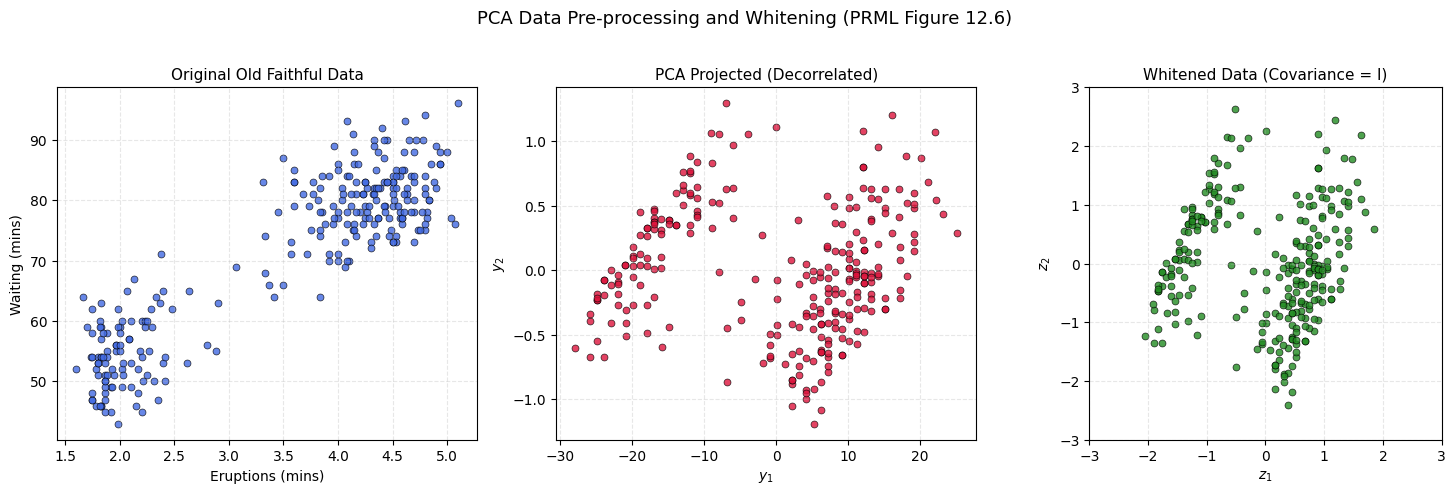

In [2]:
import pandas as pd

# Old Faithful データセットの読み込み
df = pd.read_csv('../common/faithful.csv')
X_faithful = df[['duration', 'waiting']].values

# 1. 中心化
mean_f = np.mean(X_faithful, axis=0)
X_cent = X_faithful - mean_f

# 2. 主成分回転 (PCA Transform)
pca_f = PCA(n_components=2).fit(X_faithful)
Y_rot = pca_f.transform(X_faithful)

# 3. 白色化 (Whitening: 各軸を固有値の平方根で除算)
Z_white = Y_rot / np.sqrt(pca_f.explained_variance_)

# PRML Figure 12.6 のプロット
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

# (a) 元のデータ (中心化前)
axes[0].scatter(X_faithful[:, 0], X_faithful[:, 1], color='royalblue', s=25, alpha=0.8, edgecolors='k', lw=0.5)
axes[0].set_title('Original Old Faithful Data', fontsize=11)
axes[0].set_xlabel('Eruptions (mins)', fontsize=10); axes[0].set_ylabel('Waiting (mins)', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.3)

# (b) 主成分軸への回転 (無相関化)
axes[1].scatter(Y_rot[:, 0], Y_rot[:, 1], color='crimson', s=25, alpha=0.8, edgecolors='k', lw=0.5)
axes[1].set_title('PCA Projected (Decorrelated)', fontsize=11)
axes[1].set_xlabel('$y_1$', fontsize=10); axes[1].set_ylabel('$y_2$', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.3)

# (c) 白色化 (球状化: 共分散行列 = I)
axes[2].scatter(Z_white[:, 0], Z_white[:, 1], color='forestgreen', s=25, alpha=0.8, edgecolors='k', lw=0.5)
axes[2].set_title('Whitened Data (Covariance = I)', fontsize=11)
axes[2].set_xlabel('$z_1$', fontsize=10); axes[2].set_ylabel('$z_2$', fontsize=10)
axes[2].set_xlim(-3, 3); axes[2].set_ylim(-3, 3)
axes[2].set_aspect('equal', 'box')
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('PCA Data Pre-processing and Whitening (PRML Figure 12.6)', fontsize=13, y=1.02)
plt.tight_layout()
save_plot(fig, 'result', 'fig12_6_pca_whitening_faithful.png')
plt.show()